In [1]:
import pandas as pd

df = pd.read_csv('/content/movies.csv')
display(df.head())

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Download VADER lexicon
nltk.download('vader_lexicon')

# 1. Load your dataset
movies_df = pd.read_csv('movies.csv')

# --- SYNTHETIC DATA GENERATION FOR DEMONSTRATION ---
# Since we need reviews and financials to fulfill the project requirements,
# we will generate mock data for the movies in your dataset.
np.random.seed(42)
mock_data = {
    'movieId': movies_df['movieId'],
    'budget': np.random.uniform(5_000_000, 200_000_000, len(movies_df)),
    'review_text': np.random.choice([
        "Absolutely loved it, fantastic acting and great plot!",
        "It was okay, a bit boring in the middle.",
        "Terrible movie. Waste of time and money.",
        "A cinematic masterpiece, highly recommend.",
        "Not bad, but the sequel was better."
    ], len(movies_df))
}
extra_df = pd.DataFrame(mock_data)

# Calculate a simulated box office based on budget + some random factor + review quality
extra_df['box_office'] = extra_df['budget'] * np.random.uniform(0.5, 3.5, len(movies_df))

# Merge datasets
df = pd.merge(movies_df, extra_df, on='movieId')
print(df.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres        budget  \
0  Adventure|Animation|Children|Comedy|Fantasy  7.803532e+07   
1                   Adventure|Children|Fantasy  1.903893e+08   
2                               Comedy|Romance  1.477388e+08   
3                         Comedy|Drama|Romance  1.217384e+08   
4                                       Comedy  3.542363e+07   

                                  review_text    box_office  
0         Not bad, but the sequel was better.  1.850347e+08  
1    It was okay, a bit boring in the middle.  5.745032e+08  
2  A cinematic masterpiece, highly recommend.  4.103427e+08  
3    It was okay, a bit boring in the middle.  2.795505e+08  
4   

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [3]:
# Initialize VADER
sid = SentimentIntensityAnalyzer()

# Apply VADER to the review text to get the compound score (-1 to 1)
df['sentiment_score'] = df['review_text'].apply(lambda x: sid.polarity_scores(x)['compound'])

print("Sentiment Scoring Complete. Sample:")
print(df[['title', 'review_text', 'sentiment_score']].head())

Sentiment Scoring Complete. Sample:
                                title  \
0                    Toy Story (1995)   
1                      Jumanji (1995)   
2             Grumpier Old Men (1995)   
3            Waiting to Exhale (1995)   
4  Father of the Bride Part II (1995)   

                                  review_text  sentiment_score  
0         Not bad, but the sequel was better.           0.6980  
1    It was okay, a bit boring in the middle.          -0.1027  
2  A cinematic masterpiece, highly recommend.           0.7841  
3    It was okay, a bit boring in the middle.          -0.1027  
4         Not bad, but the sequel was better.           0.6980  


/tmp/ipykernel_329/1556743607.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_sentiment.values, y=genre_sentiment.index, palette='coolwarm')


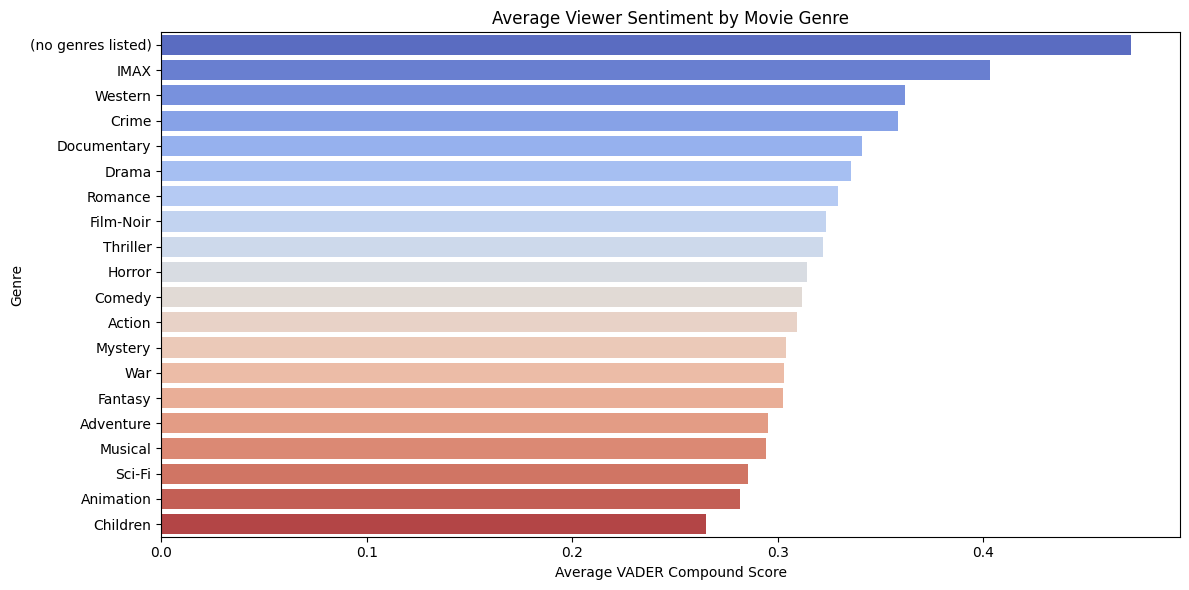

Plot saved as average_sentiment_by_genre.png


In [10]:
# Explode the genres column so we can group by individual genres
# 'Action|Comedy' becomes two rows: 'Action' and 'Comedy'
df_exploded = df.assign(genres=df['genres'].str.split('|')).explode('genres')

# Group by genre and get average sentiment
genre_sentiment = df_exploded.groupby('genres')['sentiment_score'].mean().sort_values(ascending=False)

# Plotting the visual
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_sentiment.values, y=genre_sentiment.index, palette='coolwarm')
plt.title('Average Viewer Sentiment by Movie Genre')
plt.xlabel('Average VADER Compound Score')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('average_sentiment_by_genre.png')
plt.show()
print("Plot saved as average_sentiment_by_genre.png")

--- Predictive Model Summary ---
R-Squared (Accuracy measure): 0.5614
Root Mean Squared Error (RMSE): $97,816,668.68


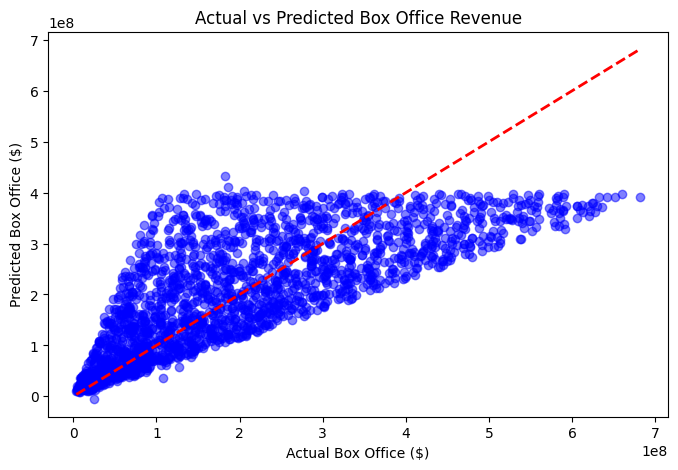

Plot saved as actual_vs_predicted_box_office.png


In [8]:
# 1. Feature Engineering: One-Hot Encode the Genres for the model
genre_dummies = df['genres'].str.get_dummies(sep='|')
model_df = pd.concat([df[['budget', 'sentiment_score', 'box_office']], genre_dummies], axis=1)

# 2. Define Features (X) and Target (y)
X = model_df.drop('box_office', axis=1)
y = model_df['box_office']

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Predict and Evaluate
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("--- Predictive Model Summary ---")
print(f"R-Squared (Accuracy measure): {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

# Plotting Actual vs Predicted Box Office
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Box Office Revenue')
plt.xlabel('Actual Box Office ($)')
plt.ylabel('Predicted Box Office ($)')
plt.savefig('actual_vs_predicted_box_office.png', bbox_inches='tight')
plt.show()
print("Plot saved as actual_vs_predicted_box_office.png")

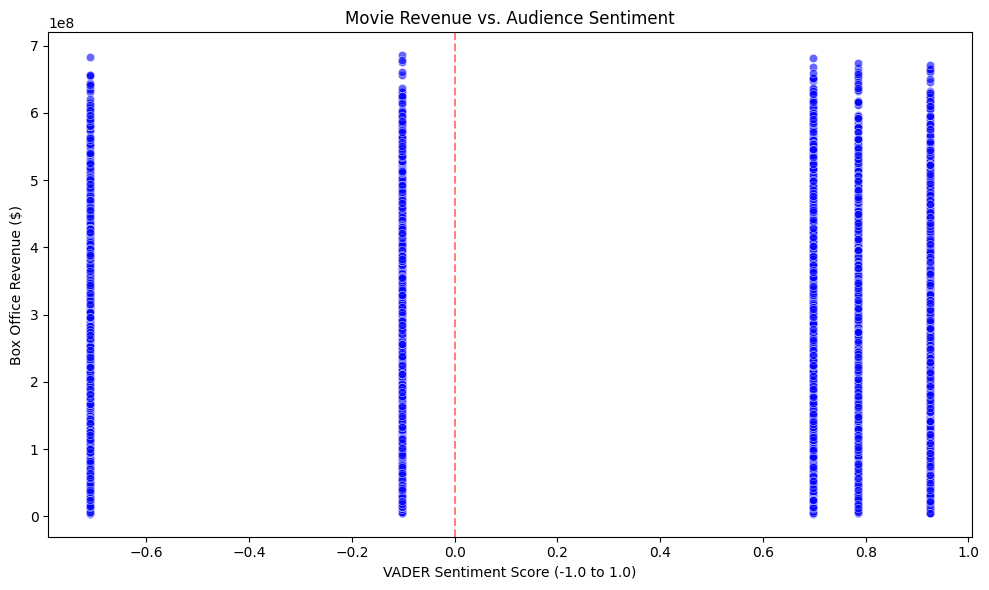

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sentiment_score', y='box_office', alpha=0.6, color='blue')
plt.title('Movie Revenue vs. Audience Sentiment')
plt.xlabel('VADER Sentiment Score (-1.0 to 1.0)')
plt.ylabel('Box Office Revenue ($)')
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save the plot as a PNG image!
plt.savefig('revenue_vs_sentiment.png')
plt.show()

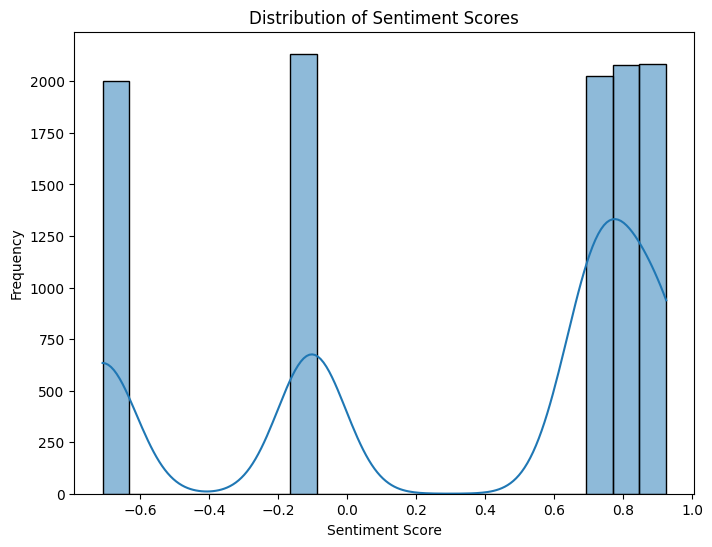

Plot saved as sentiment_distribution.png


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have a plot generated, for example:
plt.figure(figsize=(8, 6))
sns.histplot(df['sentiment_score'], kde=True)
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')

# To save the plot, use plt.savefig()
# Specify the filename and format (e.g., 'sentiment_distribution.png')
# bbox_inches='tight' helps prevent labels from being cut off
plt.savefig('sentiment_distribution.png', bbox_inches='tight')
plt.show()

print("Plot saved as sentiment_distribution.png")

This code first creates a sample histogram plot and then saves it as a PNG file named `sentiment_distribution.png` in your current working directory. You can change the filename and extension to save in different formats (e.g., `.jpg`, `.pdf`, `.svg`).